In [2]:
import numpy as np
import pandas as pd
pd.set_option("display.max_columns", None)
from boosting import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


In [3]:
%run exploratory_analysis.py

No existe ningún dato faltante.

Distribución de clases:
abandono - 1421 - 32.12%
graduado - 2209 - 49.93%
matriculado - 794 - 17.95%

--- INICIO PREPROCESADO FEATURES ---

[Binarias]
 - asistencia_diurna_vespertina → 0=diurna, 1=vespertina
 - becado → 0=no, 1=si
 - desplazado → 0=no, 1=si
 - deudor → 0=no, 1=si
 - genero → 0=hombre, 1=mujer
 - internacional → 0=no, 1=si
 - matricula_al_dia → 0=no, 1=si
 - necesidades_educativas_especiales → 0=no, 1=si

[Ordinales]
 - cualificacion_previa → escala ordinal educativa
 - cualificacion_madre → escala ordinal educativa
 - cualificacion_padre → escala ordinal educativa

[Categóricas → dummies / reducción]
 - estado_civil → one-hot encoding
 - nacionalidad → binaria (portuguesa vs resto)
 - modo_solicitud → agrupación + one-hot
 - curso → agrupación en categorías + one-hot
 - ocupacion_madre/padre → agrupación por sector + one-hot

[Reducción de variables]
 - ratios académicos (presentación y éxito por semestre)
 - eliminación de variables re

In [4]:
data = pd.read_csv("rendimiento_estudiantes_procesado.csv", sep=";", encoding="utf-8")

#### QUEREMOS CONSTRUIR UN MODELO DE REGRSION SUPERVISADA PARA PREDECIR LA VARIABLE nota_media_2sem

In [5]:
X = data.drop(columns=["ratio_presentacion_2sem", "ratio_exito_2sem", "nota_media_2sem", "objetivo"])
y = data["nota_media_2sem"]


ELIMINACION DE LAS VARIABLES QUE PUEDEN PROVOCAR DATA LEAKEAGE

AHORA PARTIREMOS EL DATASET EN TRAIN Y TEST CON UNA TASA DE 0.8

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, shuffle=True) #permutacion de los datos

## Probamos hiperparámetros for max_depth y n_estimadores

In [7]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

param_grid = {
    'n_estimators': [5, 10, 20, 30, 40, 50],
    'max_depth': [1, 2, 3, 4, 5]
}

best_rmse = np.inf
best_params = None

kf = KFold(n_splits=3, shuffle=True, random_state=42)

# Diccionario para guardar, para cada n_estimators,
# los RMSE obtenidos al variar max_depth
rmse_by_estimators = {}

for n_est in param_grid['n_estimators']:
    rmse_by_estimators[n_est] = []

    for depth in param_grid['max_depth']:
        fold_rmses = []

        for train_idx, val_idx in kf.split(X_train):
            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

            gb = GradientBoostingRegressor(
                n_estimators=n_est,
                max_depth=depth
            )

            gb.fit(X_tr, y_tr)
            y_pred = gb.predict(X_val)

            rmse = np.sqrt(mean_squared_error(y_val, y_pred))
            fold_rmses.append(rmse)

            # Corte temprano opcional
            if np.mean(fold_rmses) > best_rmse:
                break

        mean_rmse = np.mean(fold_rmses)

        # Guardamos este RMSE medio para este n_estimators
        rmse_by_estimators[n_est].append(mean_rmse)

        # Actualizamos mejores parámetros
        if mean_rmse < best_rmse:
            best_rmse = mean_rmse
            best_params = {
                'n_estimators': n_est,
                'max_depth': depth
            }

        print(best_params, best_rmse)

final_model = GradientBoostingRegressor(**best_params)
final_model.fit(X_train, y_train)

rmse_test = np.sqrt(mean_squared_error(y_test, final_model.predict(X_test)))

print("Best params:", best_params)
print("Best CV RMSE:", round(best_rmse, 4))
print("Test RMSE:", round(rmse_test, 4))

# BOXPLOT
data = [rmse_by_estimators[n_est] for n_est in param_grid['n_estimators']]

plt.figure(figsize=(10, 6))
plt.boxplot(data, tick_labels=param_grid['n_estimators'])
plt.xlabel("n_estimators")
plt.ylabel("RMSE")
plt.title("Distribución del RMSE según n_estimators\n(variando max_depth)")
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()

{'n_estimators': 5, 'max_depth': 1} 0.21056199051023147


KeyboardInterrupt: 

In [8]:
gb = GradientBoostingRegressor(max_depth=3, n_estimators=40)
gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)


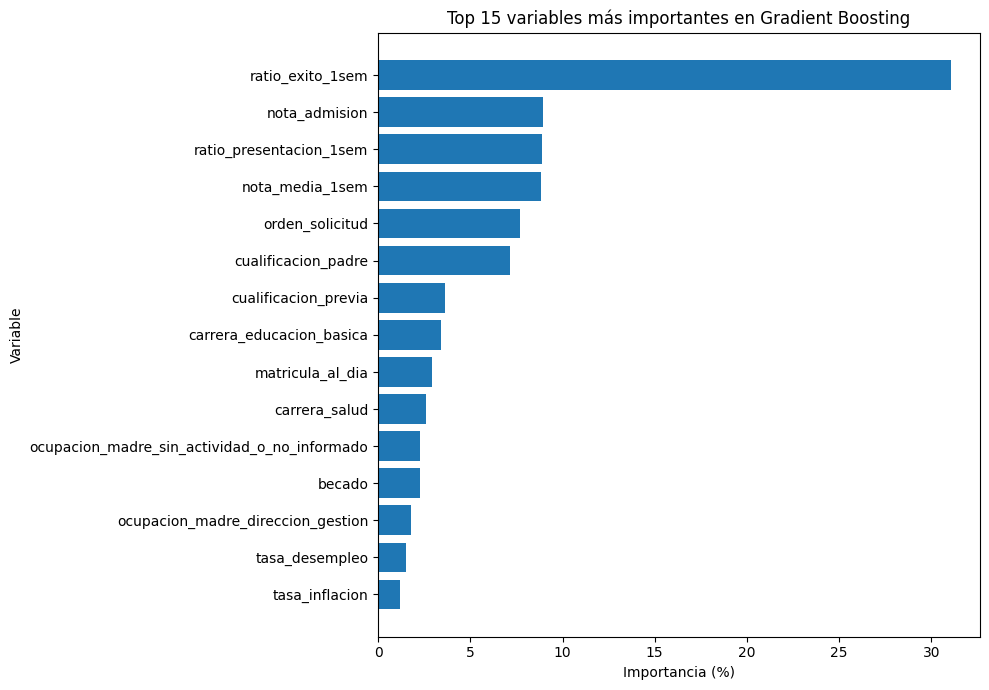

In [9]:
gb_featureimportance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gb.feature_importances_ * 100
})

# Ordenar de mayor a menor
gb_featureimportance = gb_featureimportance.sort_values("Importance", ascending=False)

# Quedarnos solo con las 15 más importantes
top_n = 15
top_features = gb_featureimportance.head(top_n).sort_values("Importance", ascending=True)

# Graficar
plt.figure(figsize=(10, 7))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importancia (%)")
plt.ylabel("Variable")
plt.title(f"Top {top_n} variables más importantes en Gradient Boosting")
plt.tight_layout()
plt.show()

RMSE: 0.128
R2: 0.796


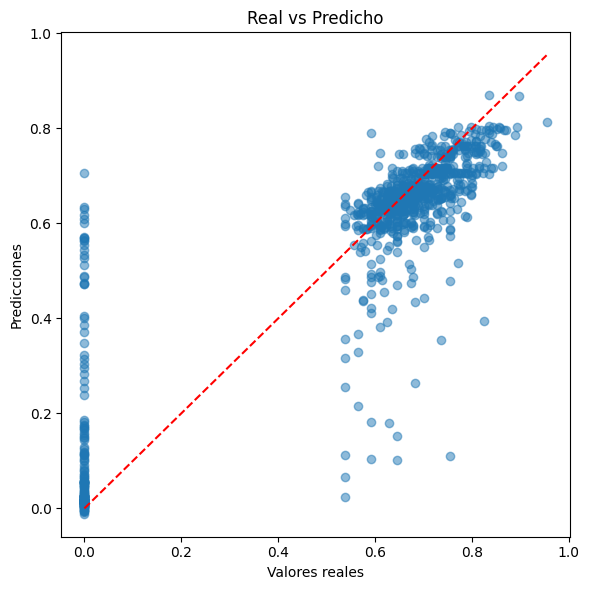

In [10]:
# Evaluación
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.3f}")
print(f"R2: {r2:.3f}")

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],'r--')

plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Real vs Predicho")
plt.tight_layout()
plt.show()